# 🧠 Gestion multi-niveaux de la mémoire dans un agent conversationnel

Ce notebook illustre les trois couches de mémoire :
- **Mémoire courte (fenêtrage de contexte)** : la partie récente de la conversation visible par le modèle.
- **Session state** : tout ce qui s’est dit pendant une session donnée (avant réinitialisation utilisateur).
- **Mémoire longue** : persistance d’informations importantes entre plusieurs sessions (historique, préférences, profil...).

In [4]:
# Imports
from collections import deque
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Simule un stockage persistant (fichier ou base de données)
LONG_TERM_STORAGE = {}

## 1️⃣ Classe de l'agent avec 3 niveaux de mémoire

In [6]:
class ConversationalAgent:
    def __init__(self, window_size=5):
        # Mémoire courte : pile de messages récents
        self.short_memory = deque(maxlen=window_size)
        
        # Session state : tout le contenu de la session courante
        self.session_memory = []
        
        # Mémoire longue : stockage persistant entre sessions
        self.long_memory = LONG_TERM_STORAGE

    def receive_message(self, user_id, message):
        # Ajouter à la mémoire courte et session
        self.short_memory.append(("user", message))
        self.session_memory.append(("user", message))

        # Simuler une réponse de l'agent
        response = self.generate_response(user_id, message)
        
        self.short_memory.append(("agent", response))
        self.session_memory.append(("agent", response))
        
        print(f"Agent: {response}\n")

    def generate_response(self, user_id, message):
        # Exemple d'utilisation de la mémoire longue :
        profile = self.long_memory.get(user_id, {})
        name = profile.get("name", "inconnu")
        
        if "je m'appelle" in message.lower():
            name = message.split()[-1]
            self.long_memory[user_id] = {"name": name}
            return f"Enchanté {name}, je me souviendrai de toi !"

        if "qui suis-je" in message.lower():
            return f"Tu es {name}, selon ma mémoire longue."

        # Réponse contextuelle simple basée sur la mémoire courte
        if any("bonjour" in m.lower() for r, m in self.short_memory if r == "user"):
            return f"Bonjour {name} ! Comment vas-tu aujourd'hui ?"

        return f"Je vois, tu dis : '{message}'. Peux-tu préciser ?"

    def show_memories(self):
        print("\n--- MÉMOIRE COURTE ---")
        for r, m in self.short_memory:
            print(f"{r}: {m}")
        print("\n--- SESSION STATE ---")
        for r, m in self.session_memory:
            print(f"{r}: {m}")
        print("\n--- MÉMOIRE LONGUE ---")
        print(json.dumps(self.long_memory, indent=2))

## 2️⃣ Exemple d'exécution : une session complète

In [7]:
agent = ConversationalAgent(window_size=4)

# Simulation d'une session utilisateur
agent.receive_message(user_id="u1", message="Bonjour")
agent.receive_message(user_id="u1", message="Je m'appelle Alice")
agent.receive_message(user_id="u1", message="Qui suis-je ?")
agent.receive_message(user_id="u1", message="Je veux parler de musique")

# Affichage des 3 types de mémoire
agent.show_memories()

Agent: Bonjour inconnu ! Comment vas-tu aujourd'hui ?

Agent: Enchanté Alice, je me souviendrai de toi !

Agent: Tu es Alice, selon ma mémoire longue.

Agent: Je vois, tu dis : 'Je veux parler de musique'. Peux-tu préciser ?


--- MÉMOIRE COURTE ---
user: Qui suis-je ?
agent: Tu es Alice, selon ma mémoire longue.
user: Je veux parler de musique
agent: Je vois, tu dis : 'Je veux parler de musique'. Peux-tu préciser ?

--- SESSION STATE ---
user: Bonjour
agent: Bonjour inconnu ! Comment vas-tu aujourd'hui ?
user: Je m'appelle Alice
agent: Enchanté Alice, je me souviendrai de toi !
user: Qui suis-je ?
agent: Tu es Alice, selon ma mémoire longue.
user: Je veux parler de musique
agent: Je vois, tu dis : 'Je veux parler de musique'. Peux-tu préciser ?

--- MÉMOIRE LONGUE ---
{
  "u1": {
    "name": "Alice"
  }
}


## 3️⃣ Visualisation du glissement de la mémoire courte (fenêtre de contexte)

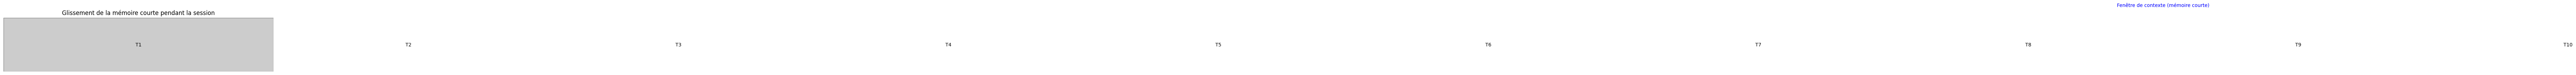

In [8]:
# Visualisation simple du glissement de la fenêtre de contexte
total_turns = 10
window_size = 4
current_turn = total_turns

fig, ax = plt.subplots(figsize=(10, 2))

for i in range(total_turns):
    rect = patches.Rectangle((i, 0), 1, 1, edgecolor='gray', facecolor='#ccc')
    ax.add_patch(rect)
    ax.text(i+0.5, 0.5, f'T{i+1}', ha='center', va='center', fontsize=10)

window_start = max(0, current_turn - window_size)
rect_window = patches.Rectangle((window_start, 0), window_size, 1, linewidth=2,
                                edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect_window)
ax.text(window_start+window_size/2, 1.2, 'Fenêtre de contexte (mémoire courte)', ha='center', color='blue')
ax.axis('off')
plt.title('Glissement de la mémoire courte pendant la session')
plt.show()

✅ **Résumé** :
- **Mémoire courte** = fenêtre glissante sur les derniers tours (utile pour GPT et context window)
- **Session state** = tout l’historique de la session active
- **Mémoire longue** = stockage persistant entre les sessions

👉 Les systèmes modernes (LangChain, LlamaIndex, OpenAI MCP) combinent ces trois approches pour créer des agents cohérents, persistants et scalables.